<a href="https://colab.research.google.com/github/withfablue/PyTorch/blob/main/Chapter4_BasicNeuralNetwork2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice: Time series prediction using LSTM

In [ ]:
# 1. Generating time series data
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

t = np.linspace(0, 100, 1000)
data = np.sin(t).astype(np.float32)

window = 20

class SineDataset(Dataset):
  def __init__(self, data, window):
    self.data = data
    self.window = window

  def __len__(self):
    return len(self.data) - self.window

  def __getitem__(self, idx):
    x = self.data[idx:idx+self.window]  # shape: (20,)
    y = self.data[idx+self.window]      # shape: ()
    return torch.tensor(x).unsqueeze(1), torch.tensor(y)   # shape: (20,1)

dataset = SineDataset(data, window)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [ ]:
# Generating time-series data
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

t = np.linspace(0, 100, 1000)
data = np.sin(t).astype(np.float32)
window = 20

class SineDataset(Dataset):
  def __init__(self, data, window):
    self.data = data
    self.window = window

  def __len__(self):
    return len(self.data) - self.window

  def __getitem__(self, idx):
    x = self.data[idx:idx+self.window]
    y = self.data[idx+self.window]
    return torch.tensor(x).unsqueeze(1), torch.tensor(y)

dataset = SineDataset(data, window)
loader = DataLoader(dataset, batch_size=32, shuffle=True)


In [ ]:
# 2. LSTM model architecture

import torch.nn as nn

class LSTMForecaster(nn.Module):
  def __init__(self):
    super().__init__()
    self.lstm = nn.LSTM(input_size=1, hidden_size=16, batch_first=True)
    self.fc = nn.Linear(16, 1)

  def forward(self, x):
    out, _ = self.lstm(x)   # out shape: (batch, 20, 16)
    last = out[:, -1, :]    # 마지막 시점의 은닉 상태
    y = self.fc(last)
    return y.squeeze(1)

model = LSTMForecaster()

In [ ]:
# LSTM model architecture
import torch.nn as nn

class LSTMForecaster(nn.Module):
  def __init__(self):
    super().__init__()
    self.lstm = nn.LSTM(input_size=1, hidden_size=16, batch_first=True)
    self.fc = nn.Linear(16, 1)

  def forward(self, x):
    out, _ = self.lstm(x)
    last = out[:, -1, :]
    y = self.fc(last)
    return y.squeeze(1)

model = LSTMForecaster()

In [ ]:
# 3. Loss function & optimizer

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# 4. Training loop
num_epochs = 5

for epoch in range(num_epochs):
  total_loss = 0.0
  for x_batch, y_batch in loader:
    optimizer.zero_grad()

    y_pred = model(x_batch)
    loss = criterion(y_pred, y_batch)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

  print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


Epoch 1, Loss: 15.1791
Epoch 2, Loss: 10.2977
Epoch 3, Loss: 5.1647
Epoch 4, Loss: 2.8004
Epoch 5, Loss: 1.0316


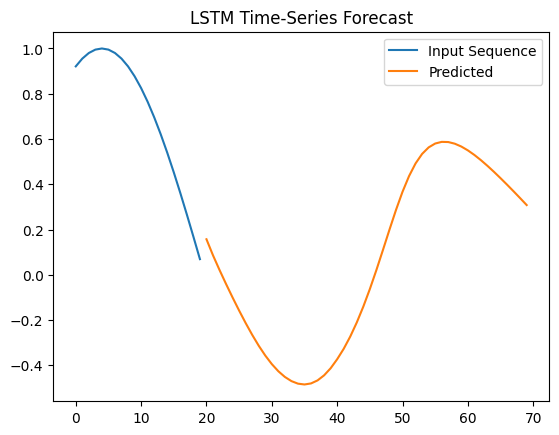

In [ ]:
# 5. Visualization
import matplotlib.pyplot as plt

model.eval()

test_input = data[200:200+window]
current = torch.tensor(test_input).unsqueeze(0).unsqueeze(2)

preds = []

for _ in range(50):
  with torch.no_grad():
    y_hat = model(current)  # shape: (1,)
  preds.append(y_hat.item())

  new_seq = torch.cat([current[:, 1:, :], y_hat.view(1, 1, 1)], dim=1)
  current = new_seq

plt.plot(range(20), test_input, label='Input Sequence')
plt.plot(range(20, 70), preds, label='Predicted')
plt.legend()
plt.title("LSTM Time-Series Forecast")
plt.show()

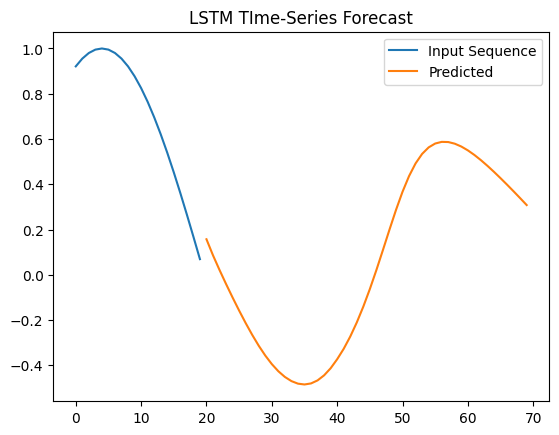

In [ ]:
# Visualization
import matplotlib.pyplot as plt

model.eval()

test_input = data[200:200+window]
current = torch.tensor(test_input).unsqueeze(0).unsqueeze(2)

preds = []

for _ in range(50):
  with torch.no_grad():
    y_hat = model(current)
  preds.append(y_hat.item())

  new_seq = torch.cat([current[:, 1:, :], y_hat.view(1, 1, 1)], dim=1)
  current = new_seq

plt.plot(range(20), test_input, label='Input Sequence')
plt.plot(range(20, 70), preds, label='Predicted' )
plt.legend()
plt.title("LSTM TIme-Series Forecast")
plt.show()

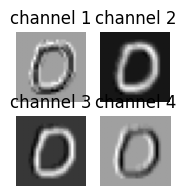

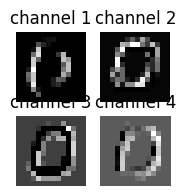

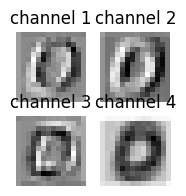

In [13]:
# Problem : CNN 중간 특징 맵 시각

import torch
import torch.nn as nn
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

class SmallCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)   # -> (B, 8, 28, 28)
    self.pool = nn.MaxPool2d(2, 2)                           # -> (B, 8, 14, 14)
    self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)  # -> (B, 16, 14, 14)
    self.fc = nn.Linear(16*14*14, 10)

  def forward(self, x):
    # 1st feature map
    x = self.conv1(x)
    indices = torch.randperm(x.size(1))[:4]
    plt.figure(figsize=(2,2))
    for i, index in enumerate(indices):
      plt.subplot(2, 2, i+1)
      plt.imshow(x[:, index, :, :].squeeze(), cmap='gray')
      plt.title(f"channel {i+1}")
      plt.axis('off')

    x = torch.relu(x)

    # 2nd feature map
    x = self.pool(x)
    indices = torch.randperm(x.size(1))[:4]
    plt.figure(figsize=(2,2))
    for i, index in enumerate(indices):
      plt.subplot(2, 2, i+1)
      plt.imshow(x[:, index, :, :].squeeze(), cmap='gray')
      plt.title(f"channel {i+1}")
      plt.axis('off')

    # 3rd feature map
    x = self.conv2(x)
    indices = torch.randperm(x.size(1))[:4]
    plt.figure(figsize=(2,2))
    for i, index in enumerate(indices):
      plt.subplot(2, 2, i+1)
      plt.imshow(x[:, index, :, :].squeeze(), cmap='gray')
      plt.title(f"channel {i+1}")
      plt.axis('off')



    plt.show()

    x = torch.relu(x)
    x = x.view(x.size(0), -1)
    x = self.fc(x)
    return x

MNIST_dataset = datasets.MNIST(
    root='data',
    train=False,
    transform=transforms.ToTensor(),
    download=True,
    )


sample_image, _ = MNIST_dataset[10]
sample_image = sample_image.unsqueeze(0)

model = SmallCNN()
model.eval()
with torch.no_grad():
  model(sample_image)




In [15]:
# Problem: RNN hidden state

import torch
import torch.nn as nn

torch.manual_seed(0)
input = torch.randn(5, 1)
RNNlayer = nn.RNN(input_size=1, hidden_size=4, num_layers=1, batch_first=True, bidirectional=False)
hidden, _ = RNNlayer(input.unsqueeze(0))
for x, h in zip(input, hidden.squeeze(0)):
  print(x, h)

tensor([1.5410]) tensor([-0.8745, -0.3010, -0.4168, -0.1949], grad_fn=<UnbindBackward0>)
tensor([-0.2934]) tensor([-0.5045, -0.0170, -0.1091,  0.0789], grad_fn=<UnbindBackward0>)
tensor([-2.1788]) tensor([ 0.3273,  0.6979,  0.2698, -0.0500], grad_fn=<UnbindBackward0>)
tensor([0.5684]) tensor([-0.6005,  0.3042, -0.0873, -0.4470], grad_fn=<UnbindBackward0>)
tensor([-1.0845]) tensor([ 0.0015,  0.3950,  0.3182, -0.2651], grad_fn=<UnbindBackward0>)
